# 01i — Pairwise Cosine Similarity Full Scan (per-category)

Experiment (as scoped with Dr. Liu):
For Llama-3.1-8B-Instruct, compute the pairwise cosine similarity between
hidden-state representations across ALL layers and ALL token positions,
for 2 harmful + 2 harmless prompts. Also compute cosine similarity of every
(layer, position) activation against the previously-extracted per-category
refusal vector (DIM, Arditi et al. methodology).

This version loops over the three harm categories (`violence`, `self_harm`,
`cybercrime`), loading each category's already-computed DIM refusal
direction from `phase1/dim_outputs/{category}/direction.pt` and 2 harmful
prompts from that category's `harmful_val.json`. The same 2 harmless
prompts are reused across all three categories as a shared baseline.

**Known confound** (Timkey & van Schijndel, EMNLP 2021 — "rogue dimensions"):
A small number of channels dominate raw cosine similarity because they
numerically overwhelm the dot product, NOT because the representations are
actually more semantically similar. Every raw similarity matrix below is
therefore paired with a z-scored / standardized version. Report the
standardized version as the primary result; raw is included for comparison.

**HF hidden_states indexing reminder** (33 tensors for this 32-layer model):
- index 0 → embedding output (no MATLAB layer equivalent)
- index i, i=1..32 → output of HF `model.model.layers[i-1]` = Dr. Liu's
  1-indexed MATLAB "layer i"

This mapping is written out explicitly to each `*_index_map.csv`.

**Outputs** (per category, per prompt, under `OUT_DIR/{category}/`):
- `{key}_cosine_raw.npy` (N x N, float32), N = 33 * seq_len
- `{key}_cosine_standardized.npy` (N x N, float32)
- `{key}_cosine_vs_refusal_vector.npy` (N, float32)
- `{key}_index_map.csv` maps row/col index -> (hf_layer, token_pos, token_str)
- `{key}_raw_heatmap.png` / `_std_heatmap.png`
- `{key}_refusal_cosine_by_layer.png` (Arditi Fig.24-style line plot)
- `{key}_refusal_cosine_heatmap.png` (layer x position heatmap of cosine sim vs. refusal vector)
- `run_log.csv` append-mode checkpoint log (one per category)

## Imports

In [1]:
import json
import random
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer

## Config — fill in / confirm before running

In [2]:
MODEL_PATH = '/home/samuel/research/llmattacks/llm-attacks/DIR/Llama-3.1-8B-Instruct'

# Anchor all paths to this notebook's directory (phase1/) rather than the
# Jupyter process's cwd, which varies depending on how the kernel was launched.
PHASE1_DIR = Path.cwd() if Path.cwd().name == "phase1" else Path.cwd() / "phase1"

OUT_DIR = PHASE1_DIR / "results" / "01i_pairwise_cosine_full_scan"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Per-category DIM refusal directions and harmful prompts, already computed
# and saved by Notebook 01c.
CATEGORIES = ["violence", "self_harm", "cybercrime"]
DIM_OUTPUTS_DIR = PHASE1_DIR / "dim_outputs"
SPLITS_DIR = PHASE1_DIR / "data" / "saladbench_splits" / "categories"

N_HARMFUL_PER_CATEGORY = 2
N_HARMLESS_SHARED = 2

# Leave as None to get a different random prompt selection on every run;
# set to a fixed int to make the selection reproducible across runs.
SEED = 42
rng = random.Random(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Load shared harmless prompts and per-category harmful prompts / refusal vectors

In [3]:
def load_harmless_prompts(n):
    """Harmless prompts are shared across categories (same ALPACA pool per
    the CLAUDE.md dataset section), so any category's harmless_val.json works."""
    path = SPLITS_DIR / CATEGORIES[0] / "harmless_val.json"
    with open(path) as f:
        data = json.load(f)
    sampled = rng.sample(data, n)
    return [rec["instruction"] for rec in sampled]


def load_category_harmful_prompts(category, n):
    path = SPLITS_DIR / category / "harmful_val.json"
    with open(path) as f:
        data = json.load(f)
    sampled = rng.sample(data, n)
    return [rec["instruction"] for rec in sampled]


def load_category_refusal_vector(category):
    direction_path = DIM_OUTPUTS_DIR / category / "direction.pt"
    metadata_path = DIM_OUTPUTS_DIR / category / "direction_metadata.json"
    direction = torch.load(direction_path, map_location="cpu")
    if direction.dim() > 1:
        direction = direction.squeeze()
    with open(metadata_path) as f:
        metadata = json.load(f)
    return direction, metadata


HARMLESS_PROMPTS = load_harmless_prompts(N_HARMLESS_SHARED)
HARMLESS_PROMPTS

['Create a sentence using the given word and make it appropriate for a professional email.',
 'Identify the type of correlation (positive, negative, or none) between two variables.']

## Load model

In [4]:
def load_model():
    tok = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_PATH, torch_dtype=torch.float32, output_hidden_states=True
    )
    model.eval().to(DEVICE)
    return tok, model


tok, model = load_model()

/home/sajib/anaconda3/envs/geometric_audit/lib/python3.8/site-packages/transformers/generation/configuration_utils.py:774: UserWarning: `return_dict_in_generate` is NOT set to `True`, but `output_hidden_states` is. When `return_dict_in_generate` is not `True`, `output_hidden_states` is ignored.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

## Extraction

In [5]:
@torch.no_grad()
def extract_hidden_states(prompt, tok, model):
    """Returns hs: (33, seq_len, 4096) float32 on CPU, and the token strings."""
    chat = [{"role": "user", "content": prompt}]
    input_ids = tok.apply_chat_template(
        chat, return_tensors="pt", add_generation_prompt=True
    ).to(DEVICE)
    out = model(input_ids, output_hidden_states=True)
    hs = torch.stack(out.hidden_states, dim=0).squeeze(1)  # (33, seq_len, 4096)
    tokens = tok.convert_ids_to_tokens(input_ids[0])
    return hs.float().cpu(), tokens


def flatten_layer_position(hs):
    """(33, T, 4096) -> (33*T, 4096) plus an explicit (hf_layer, token_pos) index map."""
    L, T, D = hs.shape
    flat = hs.reshape(L * T, D)
    index_map = [(l, t) for l in range(L) for t in range(T)]
    return flat, index_map

## Cosine similarity computations

In [6]:
def cosine_sim_matrix(flat, standardize=False):
    x = flat.clone()
    if standardize:
        mu = x.mean(dim=0, keepdim=True)
        sigma = x.std(dim=0, keepdim=True) + 1e-8
        x = (x - mu) / sigma
    x_norm = F.normalize(x, p=2, dim=1)
    return (x_norm @ x_norm.T).numpy()


def cosine_sim_to_refusal(flat, refusal_vector):
    x_norm = F.normalize(flat, p=2, dim=1)
    r_norm = F.normalize(refusal_vector.reshape(1, -1).float(), p=2, dim=1)
    return (x_norm @ r_norm.T).squeeze(1).numpy()  # (33*T,)

## Plotting

In [7]:
def plot_heatmap(mat, title, save_path, num_layers=33, seq_len=None):
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title(title)
    if seq_len:
        # gridlines at layer boundaries make the block structure legible
        for l in range(1, num_layers):
            ax.axhline(l * seq_len - 0.5, color="black", linewidth=0.2, alpha=0.3)
            ax.axvline(l * seq_len - 0.5, color="black", linewidth=0.2, alpha=0.3)
    plt.colorbar(im, ax=ax, label="cosine similarity")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)


def plot_refusal_cosine_by_layer(refusal_cos, index_map, num_layers, seq_len, title, save_path, source_layer=None):
    arr = np.array(refusal_cos).reshape(num_layers, seq_len)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(range(num_layers), arr.mean(axis=1), marker="o", label="mean over positions")
    ax.plot(range(num_layers), arr[:, -1], marker="x", linestyle="--", label="last token position")
    if source_layer is not None:
        ax.axvline(source_layer, color="gray", linestyle=":", label="extraction layer l*")
    ax.set_xlabel("HF hidden_states index (0=embed, i=output of layers[i-1])")
    ax.set_ylabel("cosine similarity with refusal vector")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)


def plot_refusal_cosine_heatmap(refusal_cos, num_layers, seq_len, title, save_path, source_layer=None):
    """(layer x position) grid of cosine similarity against the refusal vector."""
    arr = np.array(refusal_cos).reshape(num_layers, seq_len)
    fig, ax = plt.subplots(figsize=(max(6, seq_len * 0.25), 8))
    im = ax.imshow(arr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    if source_layer is not None:
        ax.axhline(source_layer, color="black", linestyle=":", linewidth=1, label="extraction layer l*")
        ax.legend()
    ax.set_xlabel("token position")
    ax.set_ylabel("HF hidden_states index (0=embed, i=output of layers[i-1])")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label="cosine similarity with refusal vector")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.close(fig)

## Per-category run

In [8]:
def run_category(category, tok, model):
    refusal_vector, metadata = load_category_refusal_vector(category)
    source_layer = metadata.get("layer")

    harmful_prompts = load_category_harmful_prompts(category, N_HARMFUL_PER_CATEGORY)
    prompts = {}
    for i, p in enumerate(harmful_prompts, start=1):
        prompts[f"harmful_{i}"] = p
    for i, p in enumerate(HARMLESS_PROMPTS, start=1):
        prompts[f"harmless_{i}"] = p

    out_dir = OUT_DIR / category
    out_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_csv = out_dir / "run_log.csv"

    for key, prompt in prompts.items():
        hs, tokens = extract_hidden_states(prompt, tok, model)
        num_layers, seq_len, _ = hs.shape
        flat, index_map = flatten_layer_position(hs)

        raw_cos = cosine_sim_matrix(flat, standardize=False)
        # std_cos = cosine_sim_matrix(flat, standardize=True)
        refusal_cos = cosine_sim_to_refusal(flat, refusal_vector)

        np.save(out_dir / f"{key}_cosine_raw.npy", raw_cos.astype(np.float32))
        # np.save(out_dir / f"{key}_cosine_standardized.npy", std_cos.astype(np.float32))
        np.save(out_dir / f"{key}_cosine_vs_refusal_vector.npy", refusal_cos.astype(np.float32))

        pd.DataFrame(
            [(l, t, tokens[t]) for (l, t) in index_map],
            columns=["hf_layer_index", "token_position", "token_str"],
        ).to_csv(out_dir / f"{key}_index_map.csv", index=True, index_label="index")

        plot_heatmap(raw_cos, f"{category}/{key}: raw pairwise cosine similarity", out_dir / f"{key}_raw_heatmap.png", num_layers, seq_len)
        # plot_heatmap(std_cos, f"{category}/{key}: standardized (z-scored) pairwise cosine similarity", out_dir / f"{key}_std_heatmap.png", num_layers, seq_len)
        plot_refusal_cosine_by_layer(
            refusal_cos, index_map, num_layers, seq_len,
            f"{category}/{key}: cosine sim vs. refusal vector",
            out_dir / f"{key}_refusal_cosine_by_layer.png",
            source_layer=source_layer,
        )
        plot_refusal_cosine_heatmap(
            refusal_cos, num_layers, seq_len,
            f"{category}/{key}: cosine sim vs. refusal vector (layer x position)",
            out_dir / f"{key}_refusal_cosine_heatmap.png",
            source_layer=source_layer,
        )

        pd.DataFrame([{
            "category": category,
            "prompt_key": key,
            "prompt": prompt,
            "num_tokens": seq_len,
            "num_layers_incl_embed": num_layers,
            "matrix_shape": f"{raw_cos.shape}",
            "refusal_vector_source_layer": source_layer,
        }]).to_csv(checkpoint_csv, mode="a", header=not checkpoint_csv.exists(), index=False)

        print(f"[done] {category}/{key}: seq_len={seq_len}  matrix={raw_cos.shape}  -> {out_dir}")

## Main — loop over all categories

In [9]:
# for category in CATEGORIES:
category = CATEGORIES[0]
run_category(category, tok, model)

[done] violence/harmful_1: seq_len=51  matrix=(1683, 1683)  -> /home/sajib/Documents/Geometric-Auditing-Framework/phase1/results/01i_pairwise_cosine_full_scan/violence
[done] violence/harmful_2: seq_len=57  matrix=(1881, 1881)  -> /home/sajib/Documents/Geometric-Auditing-Framework/phase1/results/01i_pairwise_cosine_full_scan/violence
[done] violence/harmless_1: seq_len=51  matrix=(1683, 1683)  -> /home/sajib/Documents/Geometric-Auditing-Framework/phase1/results/01i_pairwise_cosine_full_scan/violence
[done] violence/harmless_2: seq_len=53  matrix=(1749, 1749)  -> /home/sajib/Documents/Geometric-Auditing-Framework/phase1/results/01i_pairwise_cosine_full_scan/violence


## Verify saved outputs — load every .npy and print its shape

In [10]:
for npy_path in sorted(OUT_DIR.rglob("*.npy")):
    arr = np.load(npy_path)
    print(f"{npy_path.relative_to(OUT_DIR)}: shape={arr.shape}  dtype={arr.dtype}")

violence/harmful_1_cosine_raw.npy: shape=(1683, 1683)  dtype=float32
violence/harmful_1_cosine_vs_refusal_vector.npy: shape=(1683,)  dtype=float32
violence/harmful_2_cosine_raw.npy: shape=(1881, 1881)  dtype=float32
violence/harmful_2_cosine_vs_refusal_vector.npy: shape=(1881,)  dtype=float32
violence/harmless_1_cosine_raw.npy: shape=(1683, 1683)  dtype=float32
violence/harmless_1_cosine_vs_refusal_vector.npy: shape=(1683,)  dtype=float32
violence/harmless_2_cosine_raw.npy: shape=(1749, 1749)  dtype=float32
violence/harmless_2_cosine_vs_refusal_vector.npy: shape=(1749,)  dtype=float32


## Plot all cosine-vs-refusal-vector curves together

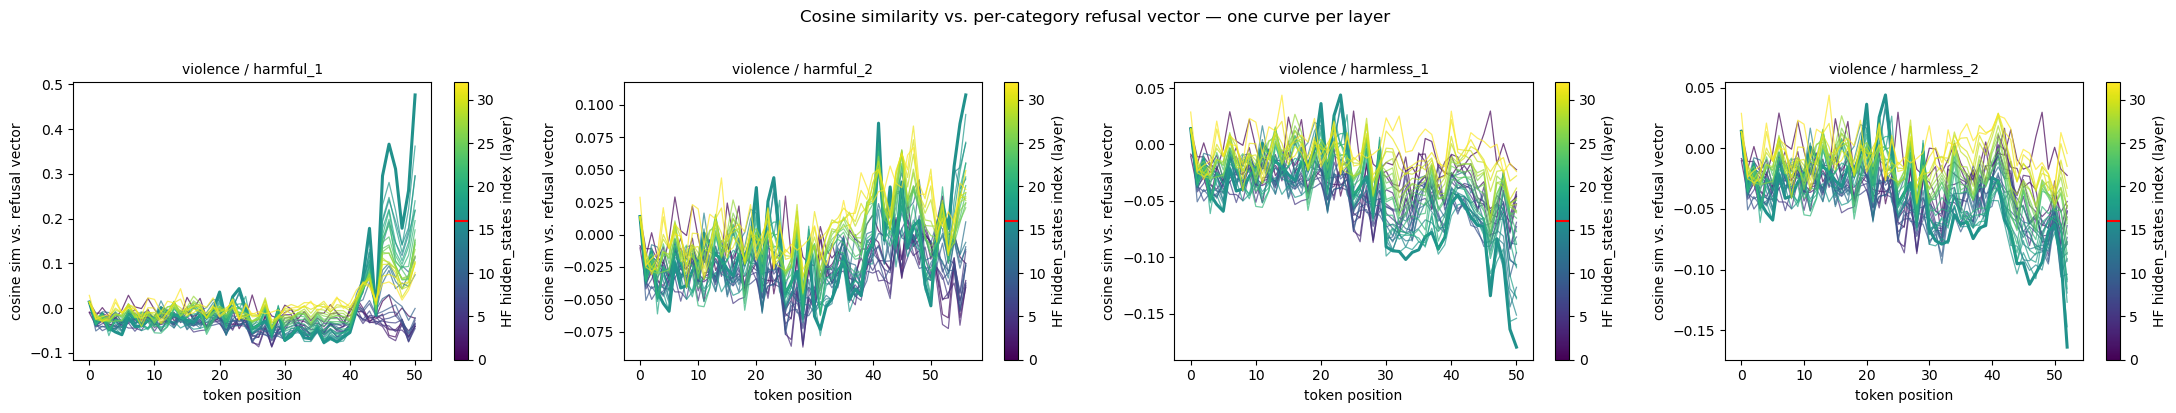

In [11]:
refusal_npy_paths = sorted(OUT_DIR.rglob("*_cosine_vs_refusal_vector.npy"))

ncols = 4
nrows = int(np.ceil(len(refusal_npy_paths) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), squeeze=False)

num_layers = 33
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(vmin=0, vmax=num_layers - 1)

for i, npy_path in enumerate(refusal_npy_paths):
    category = npy_path.parent.name
    key = npy_path.stem.replace("_cosine_vs_refusal_vector", "")
    refusal_cos = np.load(npy_path)

    seq_len = refusal_cos.shape[0] // num_layers
    arr = refusal_cos.reshape(num_layers, seq_len)  # (layer, token_position)

    _, metadata = load_category_refusal_vector(category)
    source_layer = metadata.get("layer")

    ax = axes[i // ncols][i % ncols]
    for l in range(num_layers):
        lw = 2.2 if l == source_layer else 0.9
        alpha = 1.0 if l == source_layer else 0.7
        ax.plot(range(seq_len), arr[l], color=cmap(norm(l)), linewidth=lw, alpha=alpha)

    ax.set_title(f"{category} / {key}", fontsize=10)
    ax.set_xlabel("token position")
    ax.set_ylabel("cosine sim vs. refusal vector")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("HF hidden_states index (layer)")
    if source_layer is not None:
        cbar.ax.axhline(source_layer, color="red", linewidth=1.5)

# Hide any unused subplot axes when the grid doesn't divide evenly.
for j in range(len(refusal_npy_paths), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle("Cosine similarity vs. per-category refusal vector — one curve per layer", y=1.02)
fig.tight_layout()
plt.show()

## Plot all cosine-vs-refusal-vector curves — one curve per token position

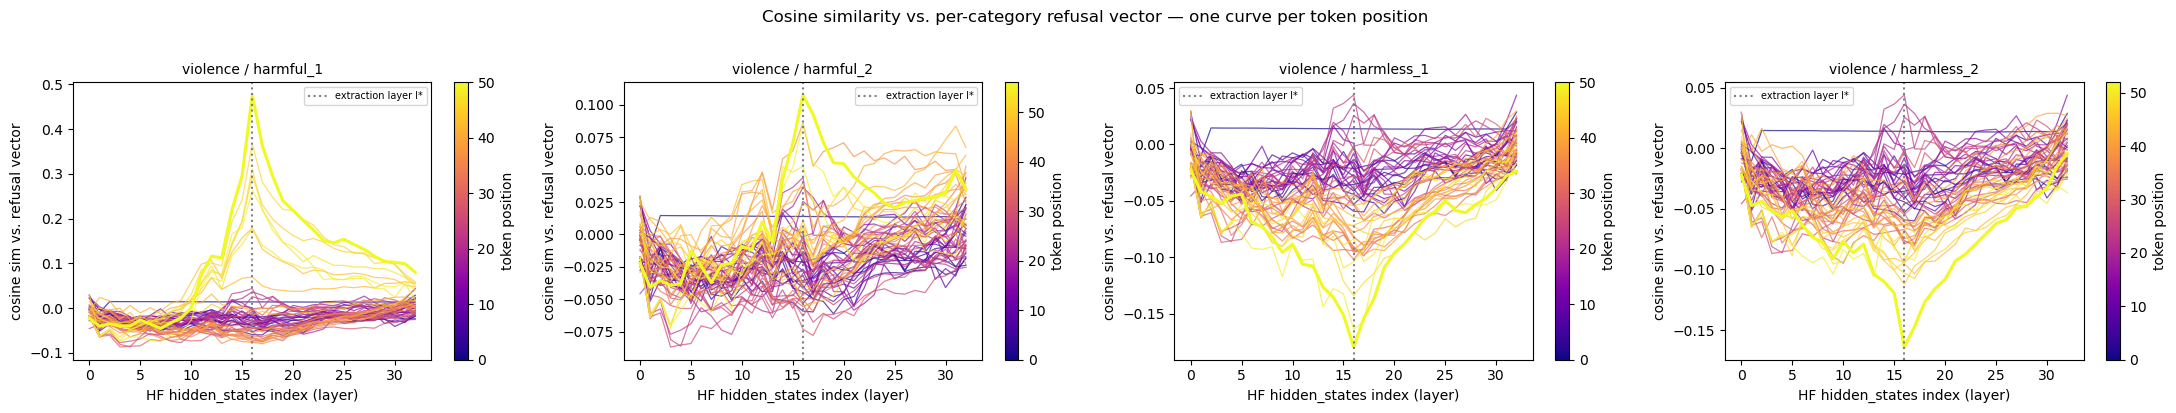

In [12]:
refusal_npy_paths = sorted(OUT_DIR.rglob("*_cosine_vs_refusal_vector.npy"))

ncols = 4
nrows = int(np.ceil(len(refusal_npy_paths) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), squeeze=False)

num_layers = 33
cmap = plt.get_cmap("plasma")

for i, npy_path in enumerate(refusal_npy_paths):
    category = npy_path.parent.name
    key = npy_path.stem.replace("_cosine_vs_refusal_vector", "")
    refusal_cos = np.load(npy_path)

    seq_len = refusal_cos.shape[0] // num_layers
    arr = refusal_cos.reshape(num_layers, seq_len)  # (layer, token_position)
    norm = plt.Normalize(vmin=0, vmax=max(seq_len - 1, 1))

    _, metadata = load_category_refusal_vector(category)
    source_layer = metadata.get("layer")

    ax = axes[i // ncols][i % ncols]
    for t in range(seq_len):
        is_last_token = t == seq_len - 1
        lw = 2.2 if is_last_token else 0.9
        alpha = 1.0 if is_last_token else 0.7
        ax.plot(range(num_layers), arr[:, t], color=cmap(norm(t)), linewidth=lw, alpha=alpha)
    if source_layer is not None:
        ax.axvline(source_layer, color="gray", linestyle=":", label="extraction layer l*")
        ax.legend(fontsize=7)

    ax.set_title(f"{category} / {key}", fontsize=10)
    ax.set_xlabel("HF hidden_states index (layer)")
    ax.set_ylabel("cosine sim vs. refusal vector")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label("token position")

# Hide any unused subplot axes when the grid doesn't divide evenly.
for j in range(len(refusal_npy_paths), nrows * ncols):
    axes[j // ncols][j % ncols].axis("off")

fig.suptitle("Cosine similarity vs. per-category refusal vector — one curve per token position", y=1.02)
fig.tight_layout()
plt.show()